In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def gradient_decent(x, y, learning_rate=0.01, iterations=1000):
    m = 0
    c = 0
    n = len(x)

    for i in range(iterations):
        y_pred = m * x + c
        error = y_pred - y
        cost = (1/n) * np.sum(error ** 2)
        md = (2/n) * np.sum(x * error)
        cd = (2/n) * np.sum(error)
        m -= learning_rate * md
        c -= learning_rate * cd

        if i % 100 == 0 or i == iterations - 1:
            print(f"iteration {i+1}: m = {m:.4f}, c = {c:.4f}, cost = {cost:.4f}")

    return m, c

In [3]:
data = pd.read_csv('data/test_scores.csv')
data

,name,math,cs
0,david,92,98
1,laura,56,68
2,sanjay,88,81
3,wei,70,80
4,jeff,80,83
5,aamir,49,52
6,venkat,65,66
7,virat,35,30
8,arthur,66,68
9,paul,67,73


In [4]:
x_original = np.array(data['math'])
y = np.array(data['cs'])

In [5]:
# Normalizing the data

x_mean = x_original.mean()
x_std = x_original.std()
x_norm = (x_original - x_mean) / x_std

In [6]:
m_norm, c_norm = gradient_decent(x_norm, y)

iteration 1: m = 0.3356, c = 1.3980, cost = 5199.1000
iteration 101: m = 14.5970, c = 60.8153, cost = 122.4901
iteration 201: m = 16.4883, c = 68.6952, cost = 33.2030
iteration 301: m = 16.7392, c = 69.7402, cost = 31.6326
iteration 401: m = 16.7724, c = 69.8788, cost = 31.6050
iteration 501: m = 16.7769, c = 69.8972, cost = 31.6045
iteration 601: m = 16.7774, c = 69.8996, cost = 31.6045
iteration 701: m = 16.7775, c = 69.9000, cost = 31.6045
iteration 801: m = 16.7775, c = 69.9000, cost = 31.6045
iteration 901: m = 16.7775, c = 69.9000, cost = 31.6045
iteration 1000: m = 16.7775, c = 69.9000, cost = 31.6045


In [7]:
# Denormalizing the parameters
# y = mx + c

# y = m * ((x - mean) / std) + c
# y = (m/std)*x + (c - m*mean/std)
m = m_norm / x_std
c = c_norm - (m_norm * x_mean) / x_std

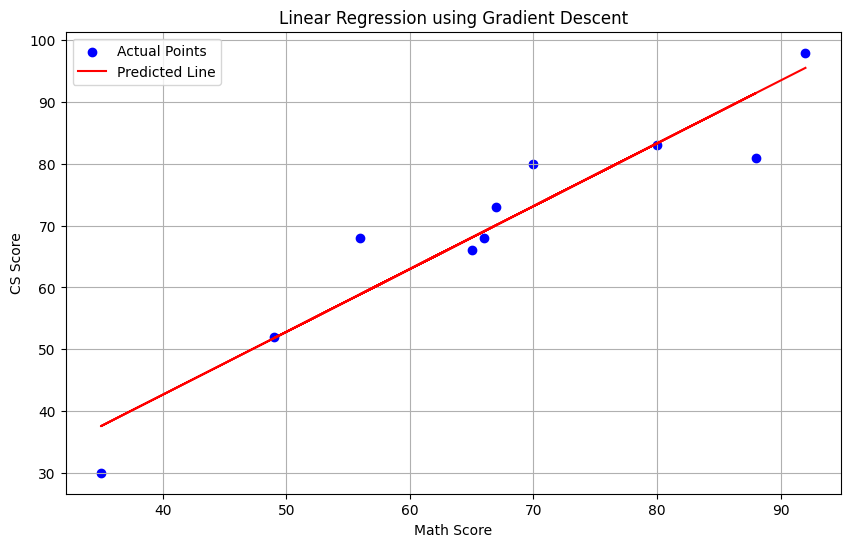

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(x_original, y, color='blue', label='Actual Points')
plt.plot(x_original, m * x_original + c, color='red', label='Predicted Line')
plt.xlabel('Math Score')
plt.ylabel('CS Score')
plt.title('Linear Regression using Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()